In [25]:
import pandas as pd

df = pd.read_csv("sales_data.csv")

df


,Order_Date,Product,Category,Quantity,Price,Profit
0,2023-01-01 00:00:00.000000000,Keyboard,Accessories,5,38658,30887
1,2023-01-02 19:53:58.190954773,Mouse,Accessories,5,55386,32366
2,2023-01-04 15:47:56.381909547,Headphones,Accessories,3,47691,14315
3,2023-01-06 11:41:54.572864321,Headphones,Accessories,5,1269,1004
4,2023-01-08 07:35:52.763819095,Tablet,Electronics,2,5811,2310
...,...,...,...,...,...,...
195,2023-12-23 16:24:07.236180904,Headphones,Accessories,1,51832,8784
196,2023-12-25 12:18:05.427135680,Mobile,Electronics,1,22333,3692
197,2023-12-27 08:12:03.618090452,Keyboard,Accessories,5,27669,19800
198,2023-12-29 04:06:01.809045228,Mobile,Electronics,5,39537,28666


In [26]:
df.shape  #Understand the Dataset Shape

(200, 6)

In [27]:
df.info()  #Column Names & Data Types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Order_Date  200 non-null    object
 1   Product     200 non-null    object
 2   Category    200 non-null    object
 3   Quantity    200 non-null    int64 
 4   Price       200 non-null    int64 
 5   Profit      200 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 9.5+ KB


In [30]:
df.describe()  #Statistical Summary


,Quantity,Price,Profit
count,200.000000,200.000000,200.000000
mean,2.970000,28885.665000,11015.565000
std,1.500117,16681.241418,10374.265472
min,1.000000,801.000000,156.000000
25%,1.750000,14975.750000,3054.500000
50%,3.000000,28622.000000,7663.000000
75%,4.000000,41349.250000,15420.250000
max,5.000000,59322.000000,48368.000000


In [31]:
df.isnull().sum()  #Check Missing Values

Order_Date    0
Product       0
Category      0
Quantity      0
Price         0
Profit        0
dtype: int64

In [32]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])  #Date Conversion

df['Order_Date']    #“Datetime conversion is required for time-based analysis like monthly or yearly trends.”

0     2023-01-01 00:00:00.000000000
1     2023-01-02 19:53:58.190954773
2     2023-01-04 15:47:56.381909547
3     2023-01-06 11:41:54.572864321
4     2023-01-08 07:35:52.763819095
                   ...             
195   2023-12-23 16:24:07.236180904
196   2023-12-25 12:18:05.427135680
197   2023-12-27 08:12:03.618090452
198   2023-12-29 04:06:01.809045228
199   2023-12-31 00:00:00.000000000
Name: Order_Date, Length: 200, dtype: datetime64[ns]

In [33]:
df['Total_Sales'] = df['Quantity'] * df['Price']   #Total Sales

df['Total_Sales']

0      193290
1      276930
2      143073
3        6345
4       11622
        ...  
195     51832
196     22333
197    138345
198    197685
199     20262
Name: Total_Sales, Length: 200, dtype: int64

In [35]:
df['Month'] = df['Order_Date'].dt.month  #Extract Month

df['Month']

0       1
1       1
2       1
3       1
4       1
       ..
195    12
196    12
197    12
198    12
199    12
Name: Month, Length: 200, dtype: int32

In [36]:
df['Total_Sales'].sum(), df['Profit'].sum()  #Total Sales & Profit


(17586250, 2203113)

In [37]:
product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
 
product_sales   #Top Products by Sales

Product
Headphones    3399496
Keyboard      3039682
Laptop        2959450
Mouse         2954121
Tablet        2899377
Mobile        2334124
Name: Total_Sales, dtype: int64

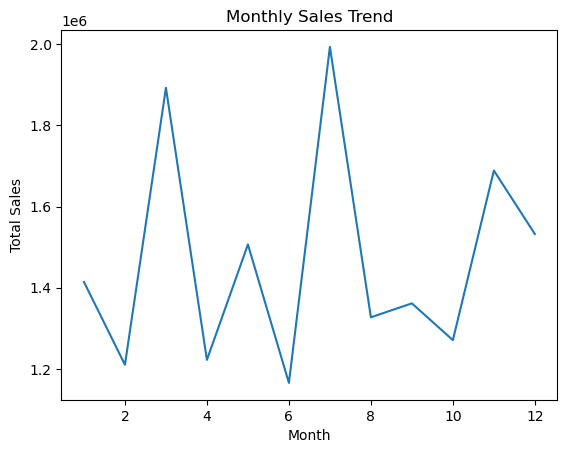

In [38]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Month')['Total_Sales'].sum()   # Monthly Sales Trend (Visualization)

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


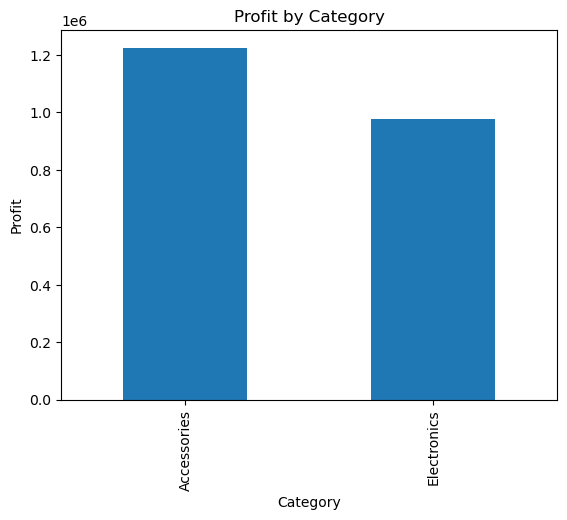

In [21]:
import matplotlib.pyplot as ply

category_profit = df.groupby('Category')['Profit'].sum()  # Profit by Category

category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()


## Business Insights

- Accessories category generated higher overall profit compared to Electronics  
- High sales volume of low-cost accessory items drove higher total revenue  
- Electronics products have higher prices but lower purchase frequency  
- Accessories provide steady income, while electronics contribute high-value transactions  
